# 03. Extracción de Bounding Boxes Ground Truth

Este notebook orquesta la extracción del Ground Truth espacial a partir de las máscaras binarias del dataset PolypSegm-ASH.
La lógica principal vive en un script CLI y aquí solo se ejecuta el proceso y se valida visualmente el resultado.

## 1. Ejecución del extractor CLI

Esta celda invoca el script de extracción de bounding boxes y muestra la salida estándar y de error para verificar el proceso.

In [12]:
import os
import subprocess
import sys
from pathlib import Path

script_path = Path('../src/preprocessing/extract_gt_bboxes.py')

jobs = [
    {
        'input_dir': Path('../data/raw'),
        'output_csv': Path('../data/raw/ground_truth_bboxes.csv'),
        'label': 'RAW -> RAW',
    },
    {
        'input_dir': Path('../data/processed'),
        'output_csv': Path('../data/processed/ground_truth_bboxes.csv'),
        'label': 'PROCESSED -> PROCESSED',
    },
]

env = os.environ.copy()
env['PYTHONIOENCODING'] = 'utf-8'

for job in jobs:
    cmd = [
        sys.executable,
        str(script_path),
        '--input-dir',
        str(job['input_dir']),
        '--output-csv',
        str(job['output_csv']),
    ]

    print(f"\n=== Ejecutando extracción: {job['label']} ===")
    print('Ejecutando comando:')
    print(' '.join(cmd))

    result = subprocess.run(
        cmd,
        capture_output=True,
        text=True,
        encoding='utf-8',
        errors='replace',
        env=env,
    )

    print('\n--- STDOUT ---')
    print(result.stdout if result.stdout else '(sin salida)')

    if result.returncode != 0:
        raise RuntimeError(
            f"El script falló para {job['label']} con código {result.returncode}."
        )

    print(f"CSV generado correctamente en: {job['output_csv']}")


=== Ejecutando extracción: RAW -> RAW ===
Ejecutando comando:
c:\Users\david\Desktop\TFG\TFG_VLM_Medical\.venv\Scripts\python.exe ..\src\preprocessing\extract_gt_bboxes.py --input-dir ..\data\raw --output-csv ..\data\raw\ground_truth_bboxes.csv

--- STDOUT ---

=== Resumen de extracción de Ground Truth BBoxes ===
Entrada: ..\data\raw
Total máscaras procesadas: 901
CSV generado: ..\data\raw\ground_truth_bboxes.csv

CSV generado correctamente en: ..\data\raw\ground_truth_bboxes.csv

=== Ejecutando extracción: PROCESSED -> PROCESSED ===
Ejecutando comando:
c:\Users\david\Desktop\TFG\TFG_VLM_Medical\.venv\Scripts\python.exe ..\src\preprocessing\extract_gt_bboxes.py --input-dir ..\data\processed --output-csv ..\data\processed\ground_truth_bboxes.csv

--- STDOUT ---

=== Resumen de extracción de Ground Truth BBoxes ===
Entrada: ..\data\processed
Total máscaras procesadas: 901
CSV generado: ..\data\processed\ground_truth_bboxes.csv

CSV generado correctamente en: ..\data\processed\ground_tru

## 2. Sanity Check visual de BBoxes (grid 4x4)

Se seleccionan 4 image_id comunes entre ambos CSV y se muestran en una cuadrícula de 4 filas x 4 columnas:
- Fila 1: máscara de raw con su BBox.
- Fila 2: imagen de raw con su BBox.
- Fila 3: máscara de processed con su BBox.
- Fila 4: imagen de processed con su BBox.

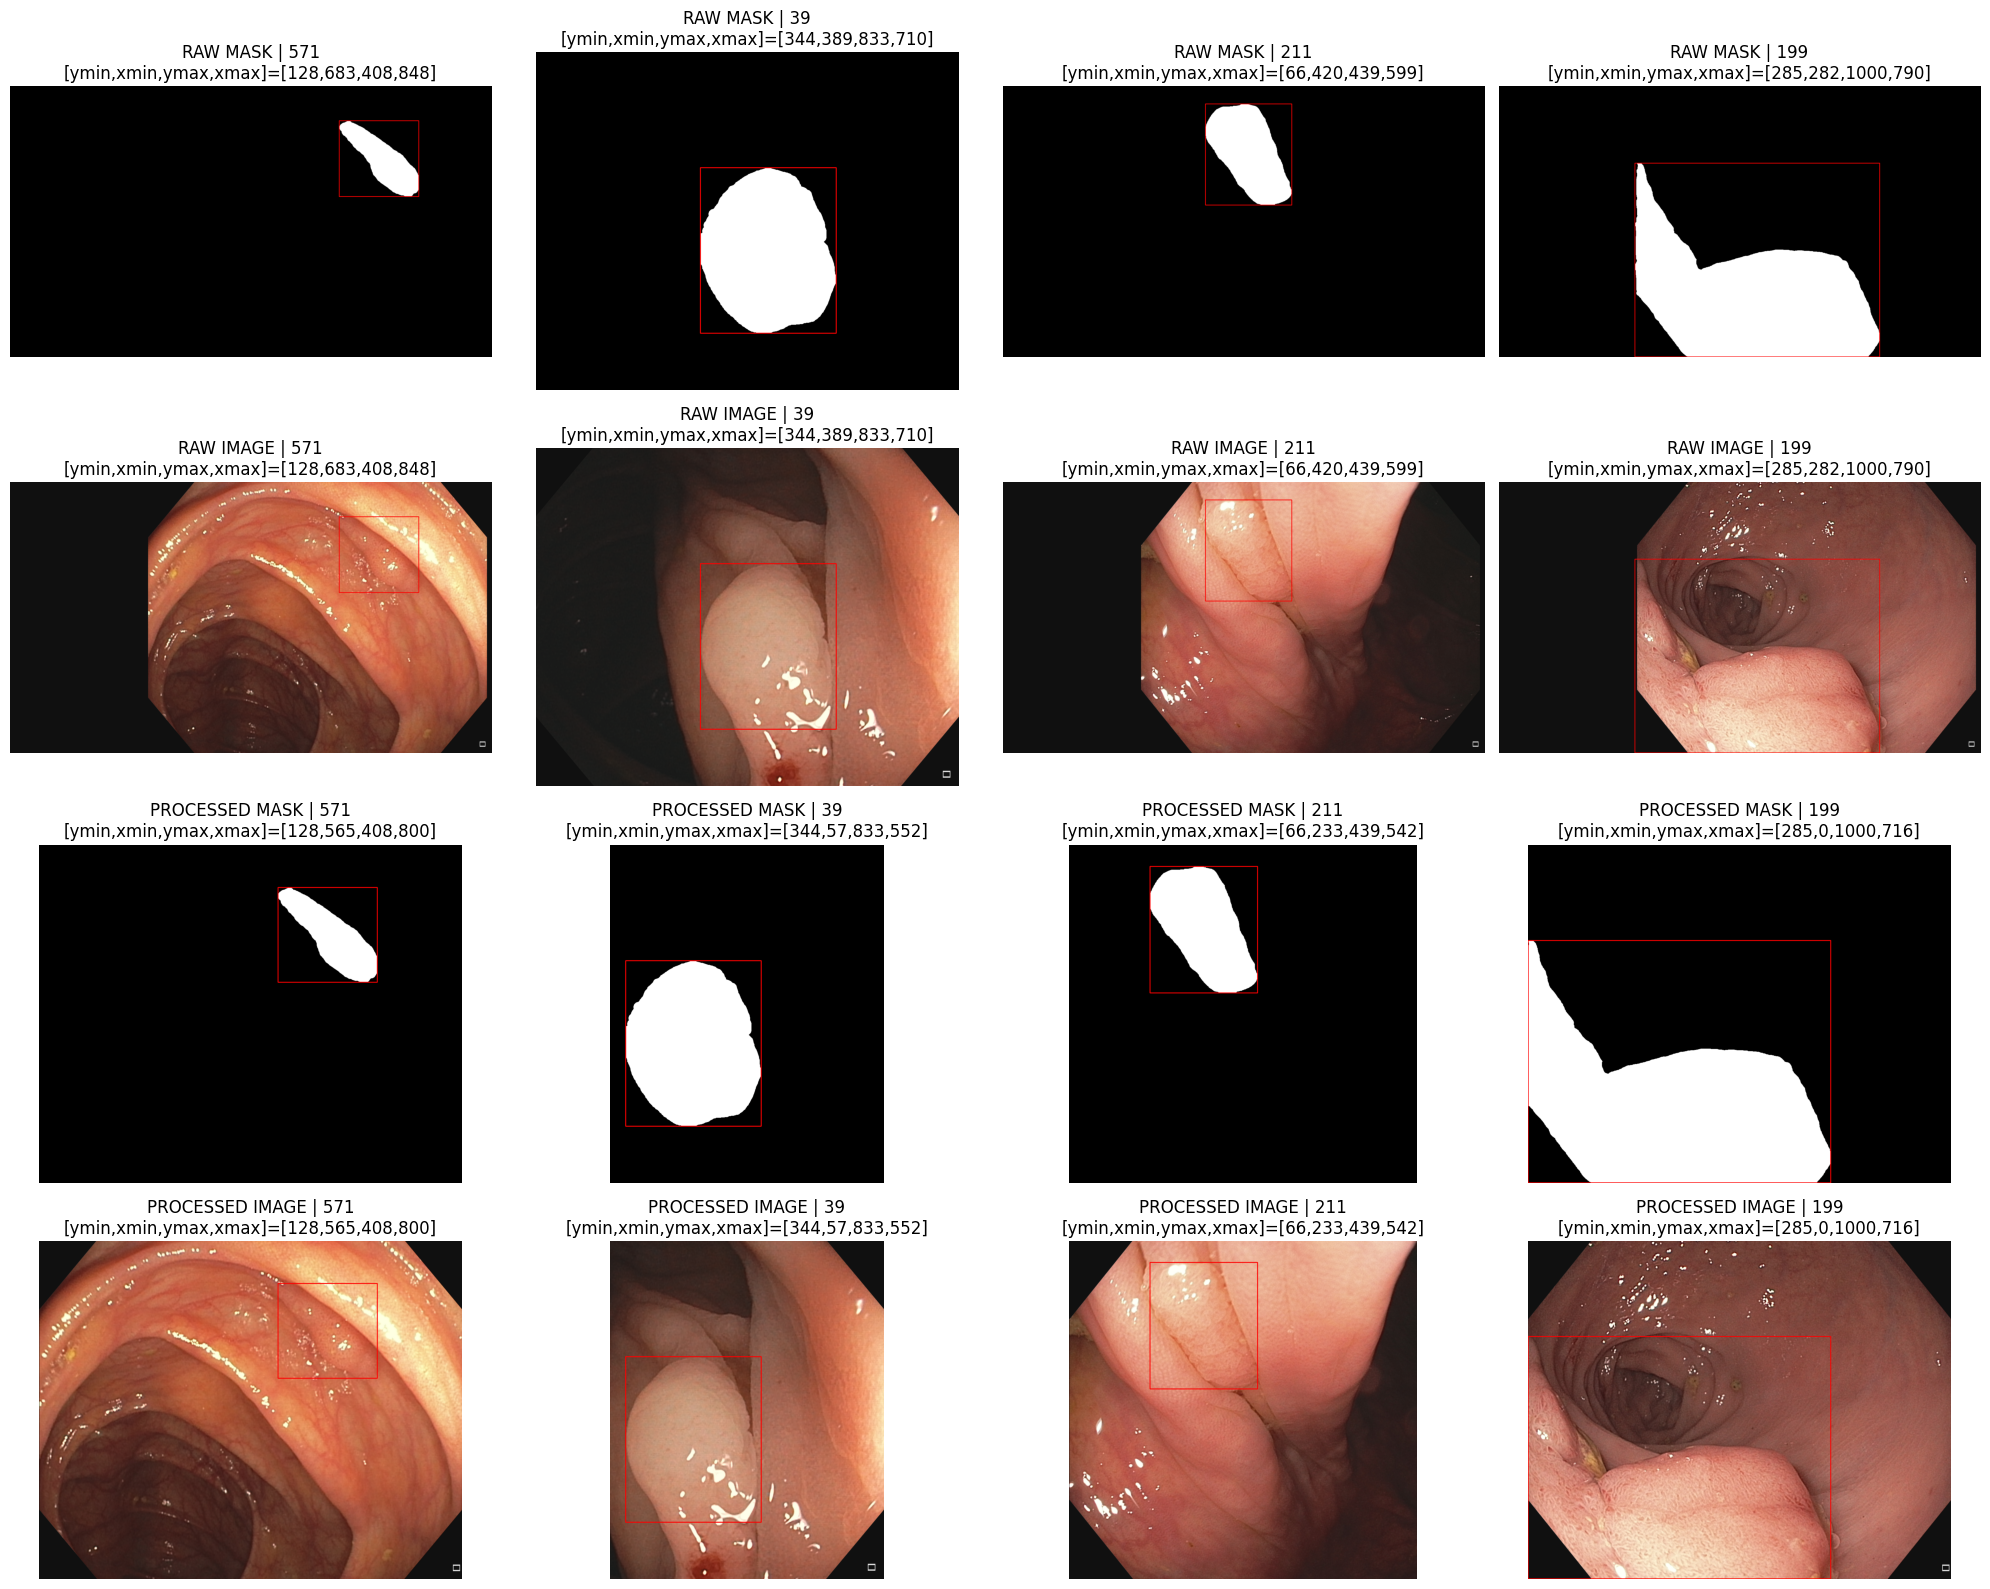

In [13]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def decode_bbox(row: pd.Series, height: int, width: int) -> tuple[int, int, int, int, str]:
    ymin_norm = int(row['ymin'])
    xmin_norm = int(row['xmin'])
    ymax_norm = int(row['ymax'])
    xmax_norm = int(row['xmax'])

    xmin = int((xmin_norm / 1000) * width)
    ymin = int((ymin_norm / 1000) * height)
    xmax = int((xmax_norm / 1000) * width)
    ymax = int((ymax_norm / 1000) * height)

    xmin = max(0, min(xmin, width - 1))
    xmax = max(0, min(xmax, width - 1))
    ymin = max(0, min(ymin, height - 1))
    ymax = max(0, min(ymax, height - 1))

    bbox_text = f"[ymin,xmin,ymax,xmax]=[{ymin_norm},{xmin_norm},{ymax_norm},{xmax_norm}]"
    return xmin, ymin, xmax, ymax, bbox_text


def resolve_image_path(mask_path: Path) -> Path:
    images_dir = mask_path.parent.parent / 'images'
    candidates = sorted(images_dir.glob(f'{mask_path.stem}.*'))
    if not candidates:
        raise RuntimeError(f'No se encontró imagen asociada para máscara: {mask_path}')
    return candidates[0]


def draw_mask_with_bbox(row: pd.Series) -> tuple[np.ndarray, str]:
    mask_path = Path(str(row['mask_path']))
    mask_gray = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask_gray is None:
        raise RuntimeError(f'No se pudo cargar la máscara: {mask_path}')

    height, width = mask_gray.shape[:2]
    xmin, ymin, xmax, ymax, bbox_text = decode_bbox(row, height, width)

    mask_bgr = cv2.cvtColor(mask_gray, cv2.COLOR_GRAY2BGR)
    cv2.rectangle(mask_bgr, (xmin, ymin), (xmax, ymax), (0, 0, 255), 2)
    mask_rgb = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)
    return mask_rgb, bbox_text


def draw_image_with_bbox(row: pd.Series) -> tuple[np.ndarray, str]:
    mask_path = Path(str(row['mask_path']))
    image_path = resolve_image_path(mask_path)

    image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise RuntimeError(f'No se pudo cargar la imagen: {image_path}')

    height, width = image_bgr.shape[:2]
    xmin, ymin, xmax, ymax, bbox_text = decode_bbox(row, height, width)

    cv2.rectangle(image_bgr, (xmin, ymin), (xmax, ymax), (0, 0, 255), 2)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    return image_rgb, bbox_text


raw_csv_path = Path('../data/raw/ground_truth_bboxes.csv')
processed_csv_path = Path('../data/processed/ground_truth_bboxes.csv')

raw_df = pd.read_csv(raw_csv_path)
processed_df = pd.read_csv(processed_csv_path)

if raw_df.empty:
    raise RuntimeError('El CSV de raw está vacío. No hay filas para validar.')
if processed_df.empty:
    raise RuntimeError('El CSV de processed está vacío. No hay filas para validar.')

common_ids = sorted(set(raw_df['image_id']) & set(processed_df['image_id']))
if not common_ids:
    raise RuntimeError('No hay image_id comunes entre raw y processed.')

sample_size = min(4, len(common_ids))
sample_ids = pd.Series(common_ids).sample(n=sample_size, random_state=42).tolist()

raw_index = raw_df.set_index('image_id')
processed_index = processed_df.set_index('image_id')

fig, axes = plt.subplots(4, sample_size, figsize=(5 * sample_size, 16))
if sample_size == 1:
    axes = np.array(axes).reshape(4, 1)

for col, image_id in enumerate(sample_ids):
    raw_row = raw_index.loc[image_id]
    if isinstance(raw_row, pd.DataFrame):
        raw_row = raw_row.iloc[0]

    processed_row = processed_index.loc[image_id]
    if isinstance(processed_row, pd.DataFrame):
        processed_row = processed_row.iloc[0]

    raw_mask_img, raw_mask_bbox = draw_mask_with_bbox(raw_row)
    raw_image_img, raw_image_bbox = draw_image_with_bbox(raw_row)
    proc_mask_img, proc_mask_bbox = draw_mask_with_bbox(processed_row)
    proc_image_img, proc_image_bbox = draw_image_with_bbox(processed_row)

    axes[0][col].imshow(raw_mask_img)
    axes[0][col].set_title(f'RAW MASK | {image_id}\n{raw_mask_bbox}')
    axes[0][col].axis('off')

    axes[1][col].imshow(raw_image_img)
    axes[1][col].set_title(f'RAW IMAGE | {image_id}\n{raw_image_bbox}')
    axes[1][col].axis('off')

    axes[2][col].imshow(proc_mask_img)
    axes[2][col].set_title(f'PROCESSED MASK | {image_id}\n{proc_mask_bbox}')
    axes[2][col].axis('off')

    axes[3][col].imshow(proc_image_img)
    axes[3][col].set_title(f'PROCESSED IMAGE | {image_id}\n{proc_image_bbox}')
    axes[3][col].axis('off')

plt.tight_layout()
plt.show()